# Machine Learning ( **Water Potability Classification** )

In [46]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
import seaborn as sns
import joblib


In [47]:
#Dataset
from google.colab import files
uploaded = files.upload()

Saving water_potability.csv to water_potability (1).csv


In [48]:
df = pd.read_csv('water_potability.csv')

In [49]:
#Dataset Shape
df.shape

(3276, 10)

In [50]:
#Statistical Summary
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [51]:
#Data Types+Informations
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [52]:
#Check Missing Values
print(df.isnull().sum())

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


In [53]:
#Check Duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


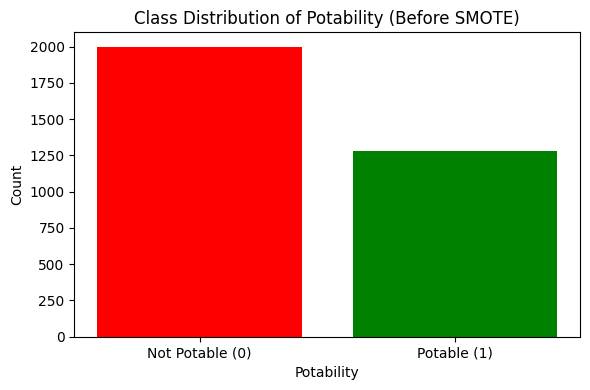

In [54]:
#Class Distribution
plt.figure(figsize=(6, 4))
counts = df['Potability'].value_counts()
plt.bar(['Not Potable (0)', 'Potable (1)'], counts.values, color=['red', 'green'])
plt.title('Class Distribution of Potability (Before SMOTE)')
plt.xlabel('Potability')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

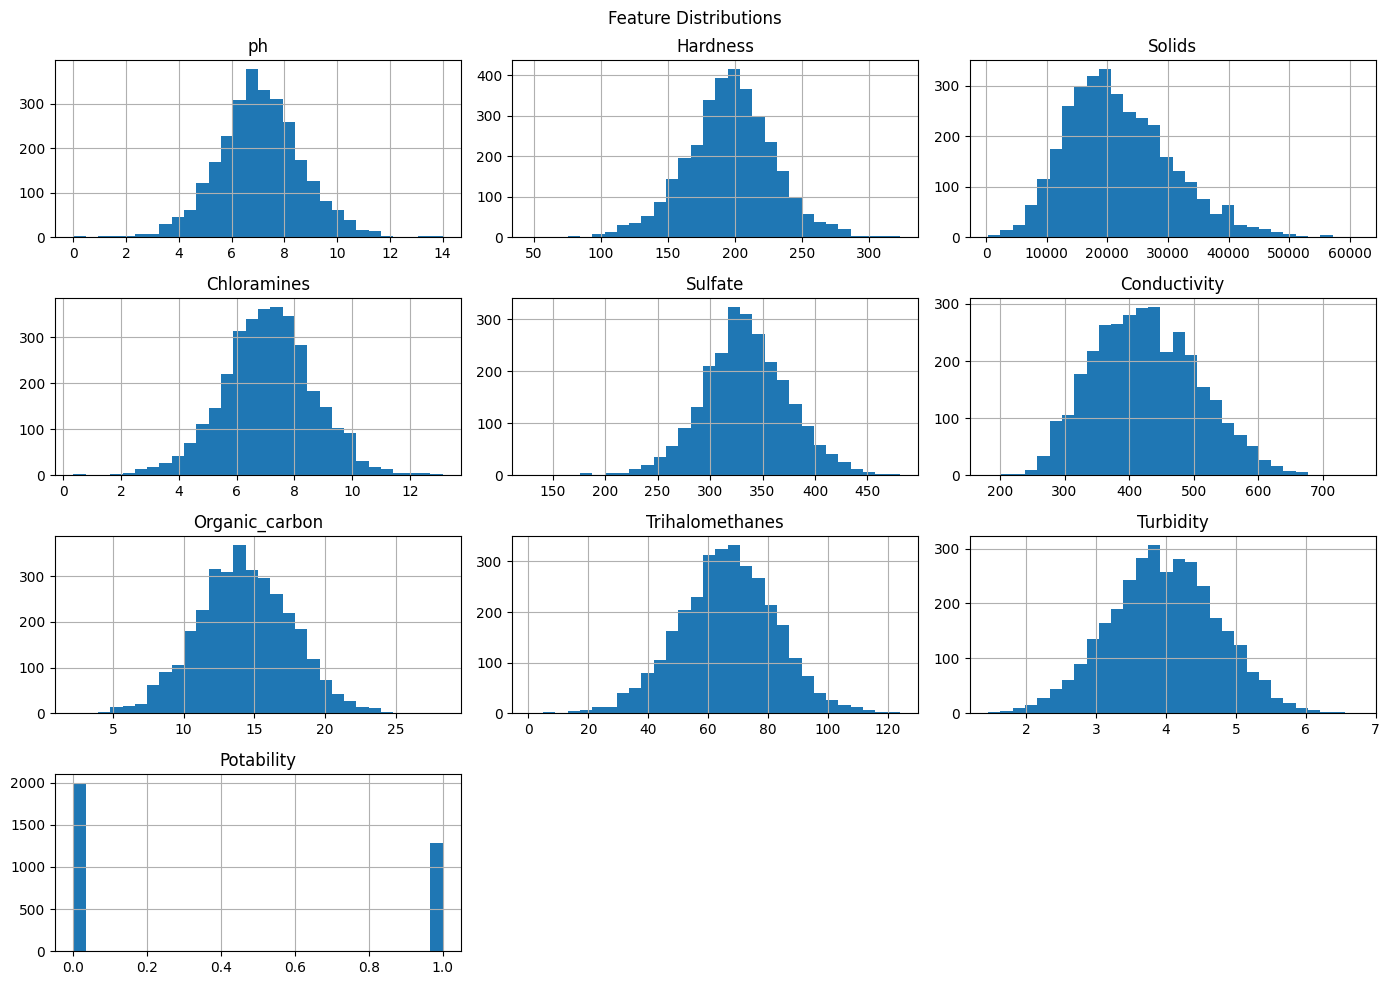

In [55]:
#Feature Distributions (Histogram)
df.hist(figsize=(14, 10), bins=30)
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()

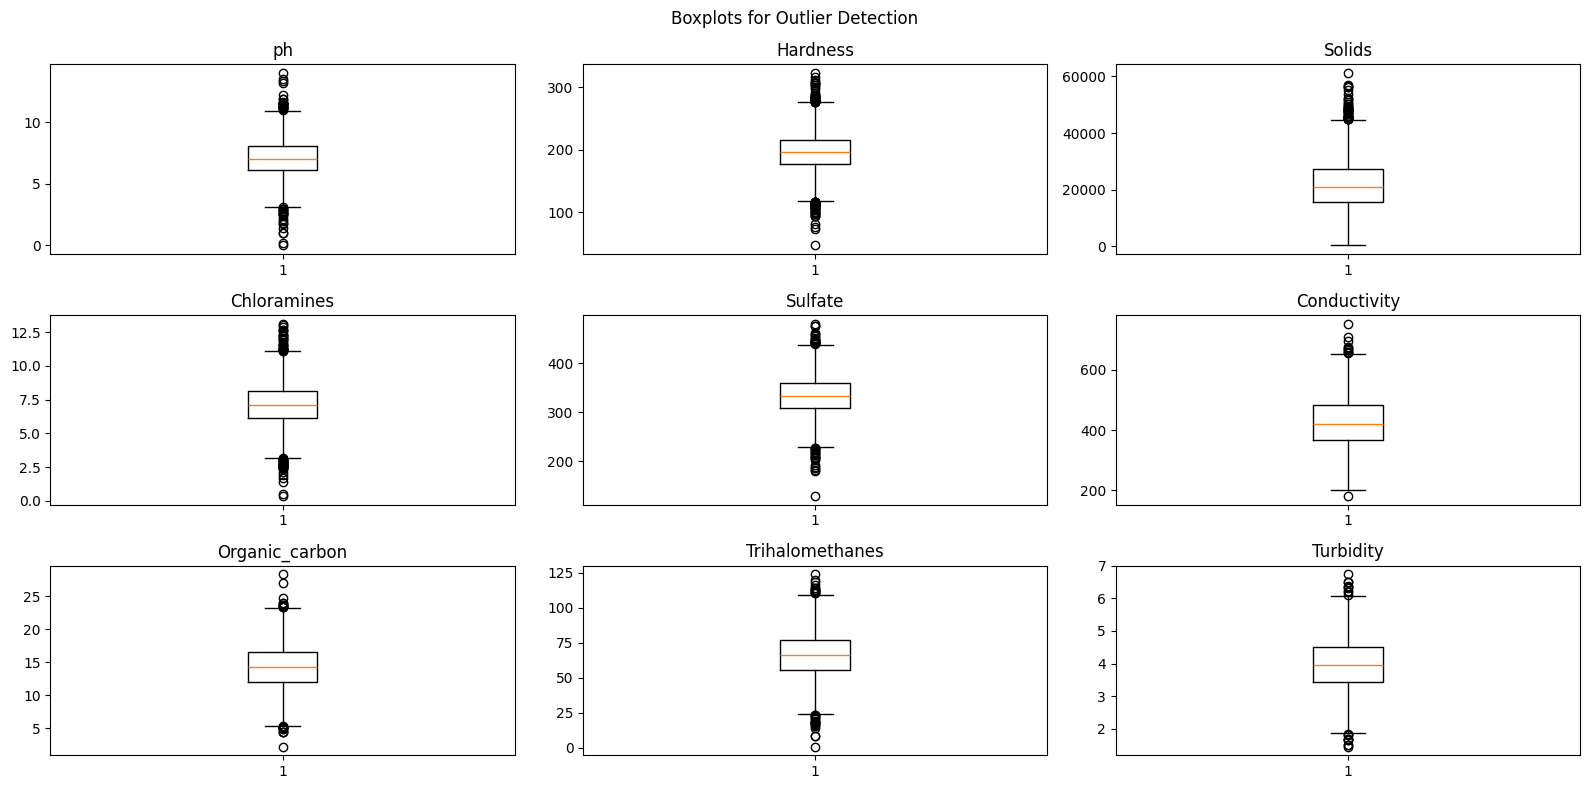

In [56]:
#Boxplots for Outlier Detection
features = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate',
            'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

plt.figure(figsize=(16, 8))
for i, col in enumerate(features):
    plt.subplot(3, 3, i + 1)
    plt.boxplot(df[col].dropna())
    plt.title(col)
plt.suptitle('Boxplots for Outlier Detection')
plt.tight_layout()
plt.show()

In [57]:
#Correlation Matrix
print(df.corr())

                       ph  Hardness    Solids  Chloramines   Sulfate  \
ph               1.000000  0.082096 -0.089288    -0.034350  0.018203   
Hardness         0.082096  1.000000 -0.046899    -0.030054 -0.106923   
Solids          -0.089288 -0.046899  1.000000    -0.070148 -0.171804   
Chloramines     -0.034350 -0.030054 -0.070148     1.000000  0.027244   
Sulfate          0.018203 -0.106923 -0.171804     0.027244  1.000000   
Conductivity     0.018614 -0.023915  0.013831    -0.020486 -0.016121   
Organic_carbon   0.043503  0.003610  0.010242    -0.012653  0.030831   
Trihalomethanes  0.003354 -0.013013 -0.009143     0.017084 -0.030274   
Turbidity       -0.039057 -0.014449  0.019546     0.002363 -0.011187   
Potability      -0.003556 -0.013837  0.033743     0.023779 -0.023577   

                 Conductivity  Organic_carbon  Trihalomethanes  Turbidity  \
ph                   0.018614        0.043503         0.003354  -0.039057   
Hardness            -0.023915        0.003610        

# Preprocessing

In [58]:

#Handle Missing Values (Mean)
df['ph'].fillna(df['ph'].mean(), inplace=True)
df['Sulfate'].fillna(df['Sulfate'].mean(), inplace=True)
df['Trihalomethanes'].fillna(df['Trihalomethanes'].mean(), inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


/tmp/ipykernel_2704/2146284455.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ph'].fillna(df['ph'].mean(), inplace=True)
/tmp/ipykernel_2704/2146284455.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [59]:
#Outlier Treatment using IQR
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].apply(lambda x: upper if x > upper else (lower if x < lower else x))



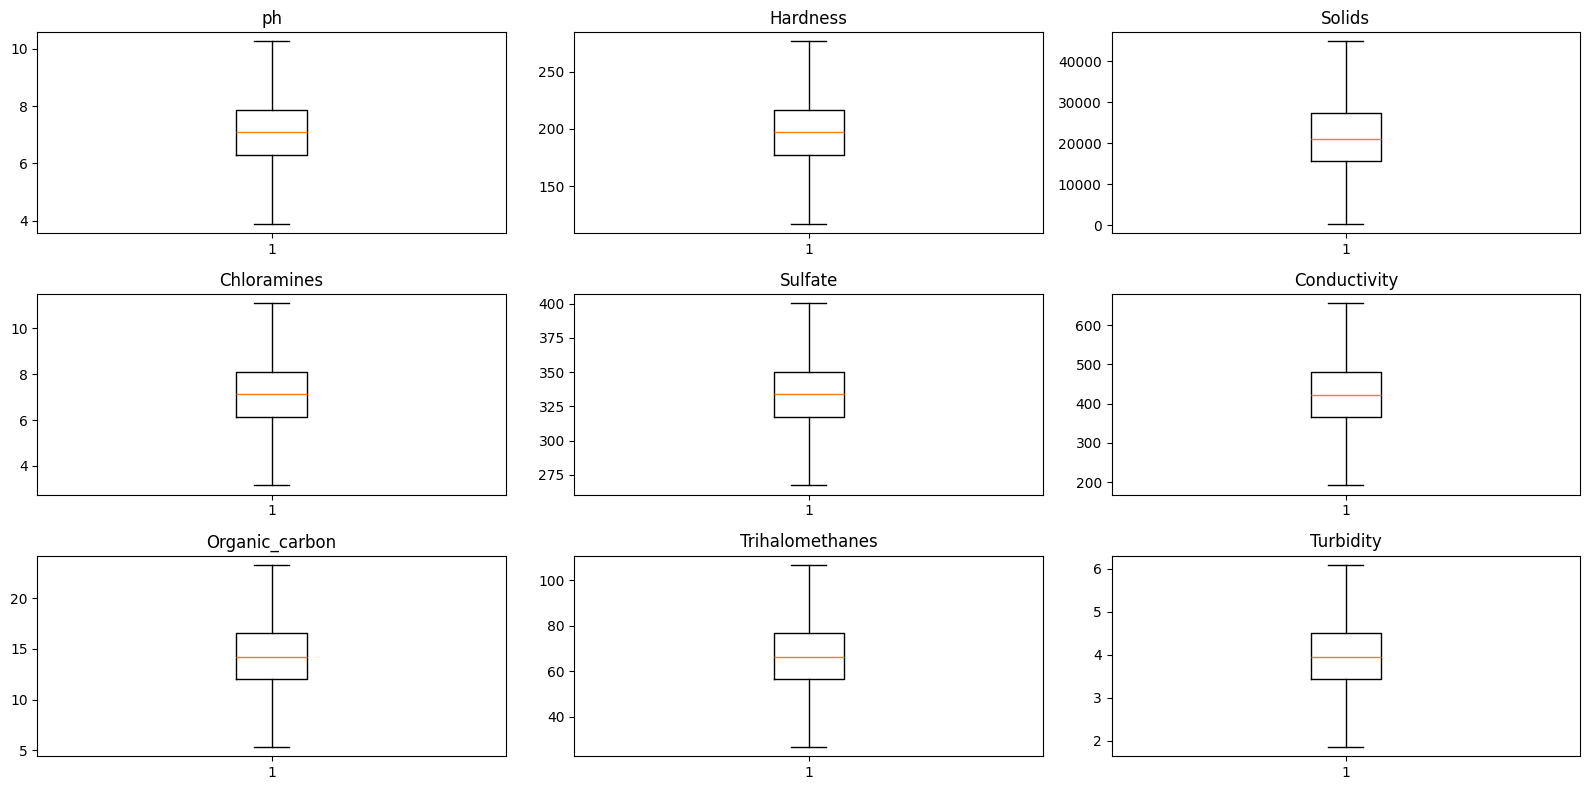

In [60]:
#Boxplots after handling outliers
features = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate',
            'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

plt.figure(figsize=(16, 8))
for i, col in enumerate(features):
    plt.subplot(3, 3, i + 1)
    plt.boxplot(df[col].dropna())
    plt.title(col)

plt.tight_layout()
plt.show()

In [61]:
#Separate Features and Target
X = df.iloc[:, :-1].values
y = df.iloc[:, 9].values

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (3276, 9)
Target shape: (3276,)


In [62]:
#Apply SMOTE To Balance The Class Distribution
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X, y)


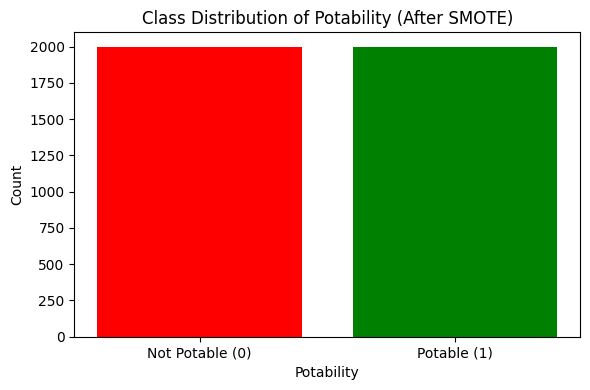

In [63]:
# Class Distribution AFTER SMOTE
plt.figure(figsize=(6, 4))
counts_smote = pd.Series(y_resampled).value_counts()

plt.bar(['Not Potable (0)', 'Potable (1)'],
        counts_smote.values,
        color=['red', 'green'])

plt.title('Class Distribution of Potability (After SMOTE)')
plt.xlabel('Potability')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

In [65]:
print("First 10 rows of preprocessed data:")
pd.DataFrame(X, columns=features).head(10)

First 10 rows of preprocessed data:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135
1,3.889107,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075
5,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708
6,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989
7,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425
8,7.080795,118.988579,14285.583854,7.804174,268.646941,389.375566,12.706049,53.928846,3.595017
9,10.258615,227.231469,25484.508491,9.077200,400.322434,563.885481,17.927806,71.976601,4.370562


 # **Models Training and Evaluation**

In [66]:
# Decision Tree Model

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

y_train_pred_dt = dt.predict(X_train)
y_pred_dt = dt.predict(X_test)

print('Training Accuracy of Decision Tree : ', accuracy_score(y_train, y_train_pred_dt))
print('Test Accuracy of Decision Tree : ', accuracy_score(y_test, y_pred_dt))

Training Accuracy of Decision Tree :  1.0
Test Accuracy of Decision Tree :  0.595


In [67]:
print("Classification Report for Decision Tree (Default):")
print(classification_report(y_test, y_pred_dt, target_names=['Not Potable (0)', 'Potable (1)']))

Classification Report for Decision Tree (Default):
                 precision    recall  f1-score   support

Not Potable (0)       0.60      0.56      0.57       394
    Potable (1)       0.59      0.63      0.61       406

       accuracy                           0.59       800
      macro avg       0.60      0.59      0.59       800
   weighted avg       0.60      0.59      0.59       800



In [68]:
# Random Forest Model
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_train_pred_rf = rf.predict(X_train)
y_pred_rf = rf.predict(X_test)


# Print the training and testing accuracy
print('Training Accuracy of Random Forest : ', accuracy_score(y_train, y_train_pred_rf))
print('Test Accuracy of Random Forest : ', accuracy_score(y_test, y_pred_rf))


Training Accuracy of Random Forest :  1.0
Test Accuracy of Random Forest :  0.7025


In [69]:
print("Classification Report for Random Forest (Default):")
print(classification_report(y_test, y_pred_rf, target_names=['Not Potable (0)', 'Potable (1)']))

Classification Report for Random Forest (Default):
                 precision    recall  f1-score   support

Not Potable (0)       0.69      0.71      0.70       394
    Potable (1)       0.71      0.70      0.70       406

       accuracy                           0.70       800
      macro avg       0.70      0.70      0.70       800
   weighted avg       0.70      0.70      0.70       800



In [70]:
# KNN Model
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

y_train_pred_knn = knn.predict(X_train)
y_pred_knn = knn.predict(X_test)

# Print the training and testing accuracy
print('Training Accuracy of KNN : ', accuracy_score(y_train, y_train_pred_knn))
print('Test Accuracy of KNN : ', accuracy_score(y_test, y_pred_knn))

Training Accuracy of KNN :  0.7443679599499374
Test Accuracy of KNN :  0.6075


In [71]:
print("Classification Report for KNN (Default):")
print(classification_report(y_test, y_pred_knn, target_names=['Not Potable (0)', 'Potable (1)']))

Classification Report for KNN (Default):
                 precision    recall  f1-score   support

Not Potable (0)       0.60      0.60      0.60       394
    Potable (1)       0.61      0.61      0.61       406

       accuracy                           0.61       800
      macro avg       0.61      0.61      0.61       800
   weighted avg       0.61      0.61      0.61       800



In [72]:
svm_default = SVC()
svm_default.fit(X_train, y_train)
y_pred_svm_default = svm_default.predict(X_test)

y_train_pred_svm = svm_default.predict(X_train)


# Print the training and testing accuracy
print('Training Accuracy of SVM  : ', accuracy_score(y_train, y_train_pred_svm))
print('Test Accuracy of SVM : ', accuracy_score(y_test, y_pred_svm_default))

Training Accuracy of SVM  :  0.518773466833542
Test Accuracy of SVM :  0.5125


In [73]:
print("Classification Report for SVM (Default):")
print(classification_report(y_test, y_pred_svm_default, target_names=['Not Potable (0)', 'Potable (1)']))

Classification Report for SVM (Default):
                 precision    recall  f1-score   support

Not Potable (0)       0.50      0.84      0.63       394
    Potable (1)       0.56      0.19      0.29       406

       accuracy                           0.51       800
      macro avg       0.53      0.52      0.46       800
   weighted avg       0.53      0.51      0.46       800



# **Model Improvement using Data Scaling**

In [74]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [75]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [76]:
svm = SVC()
svm.fit(X_train2, y_train2)

y_train_pred_svm2 = svm.predict(X_train2)
y_pred_svm2 = svm.predict(X_test2)


# Print the training and testing accuracy
print('Training Accuracy of SVM  : ', accuracy_score(y_train2, y_train_pred_svm2))
print('Test Accuracy of SVM : ', accuracy_score(y_test2, y_pred_svm2))

Training Accuracy of SVM  :  0.7290076335877863
Test Accuracy of SVM :  0.6783536585365854


# **Hyperparameter Tuning using Grid Search**

In [77]:
# SVM Tuning
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [0.01, 0.1, 1]
}

grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train2, y_train2)

print("Best Parameters:", grid.best_params_)
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test2)

print("Accuracy after tuning:", accuracy_score(y_test2, y_pred_best))

Best Parameters: {'C': 1, 'gamma': 1}
Accuracy after tuning: 0.6814024390243902


In [78]:
#Classification Report for SVM
print("Classification Report for SVM:")
print(classification_report(y_test2, y_pred_best, target_names=['Not Potable (0)', 'Potable (1)']))

Classification Report for SVM:
                 precision    recall  f1-score   support

Not Potable (0)       0.68      0.94      0.79       412
    Potable (1)       0.71      0.24      0.36       244

       accuracy                           0.68       656
      macro avg       0.69      0.59      0.57       656
   weighted avg       0.69      0.68      0.63       656



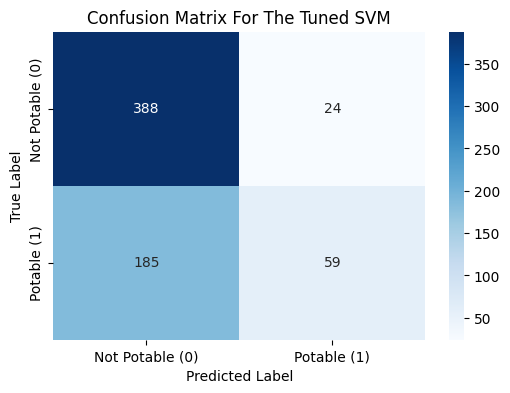

In [79]:
cm = confusion_matrix(y_test2, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Potable (0)', 'Potable (1)'],
            yticklabels=['Not Potable (0)', 'Potable (1)'])
plt.title('Confusion Matrix For The Tuned SVM')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [80]:
# Random Forest Tuning
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20]
}
grid_rf = GridSearchCV(RandomForestClassifier(), param_grid_rf, cv=5)
grid_rf.fit(X_train, y_train)
print("Best Parameters:", grid_rf.best_params_)
bmodel_rf = grid_rf.best_estimator_
y_predd_rf = bmodel_rf.predict(X_test)
print("Accuracy after tuning:", accuracy_score(y_test, y_predd_rf))

Best Parameters: {'max_depth': 20, 'n_estimators': 200}
Accuracy after tuning: 0.71625


In [81]:
#Classification Report for Random Forest
print("Classification Report for Random Forest:")
print(classification_report(y_test, y_predd_rf, target_names=['Not Potable (0)', 'Potable (1)']))

Classification Report for Random Forest:
                 precision    recall  f1-score   support

Not Potable (0)       0.71      0.71      0.71       394
    Potable (1)       0.72      0.72      0.72       406

       accuracy                           0.72       800
      macro avg       0.72      0.72      0.72       800
   weighted avg       0.72      0.72      0.72       800



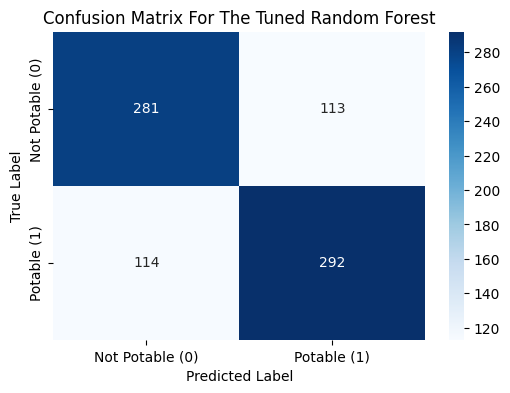

In [82]:
cm = confusion_matrix(y_test, y_predd_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Potable (0)', 'Potable (1)'],
            yticklabels=['Not Potable (0)', 'Potable (1)'])
plt.title('Confusion Matrix For The Tuned Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [83]:
# Decision Tree Tuning
param_grid_dt = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}
grid_dt = GridSearchCV(DecisionTreeClassifier(), param_grid_dt, cv=5)
grid_dt.fit(X_train, y_train)
print("Best Parameters:", grid_dt.best_params_)
best_model_dt = grid_dt.best_estimator_
y_pred_best_dt = best_model_dt.predict(X_test)
print("Accuracy after tuning:", accuracy_score(y_test, y_pred_best_dt))

Best Parameters: {'max_depth': 15, 'min_samples_split': 5}
Accuracy after tuning: 0.58625


In [84]:
# Classification Report for Decision Tree
print("\nClassification Report for the Decision Tree:")
print(classification_report(y_test, y_pred_best_dt, target_names=['Not Potable (0)', 'Potable (1)']))


Classification Report for the Decision Tree:
                 precision    recall  f1-score   support

Not Potable (0)       0.59      0.55      0.57       394
    Potable (1)       0.59      0.62      0.60       406

       accuracy                           0.59       800
      macro avg       0.59      0.59      0.59       800
   weighted avg       0.59      0.59      0.59       800



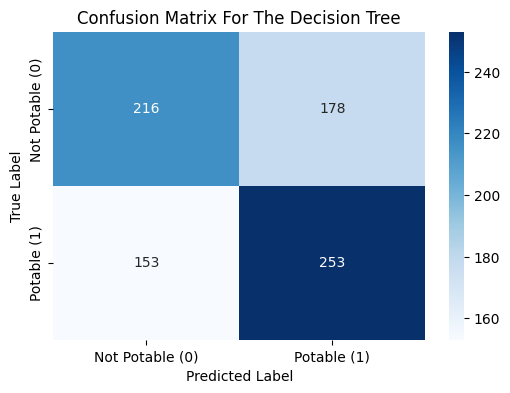

In [85]:
cm = confusion_matrix(y_test, y_pred_best_dt)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Potable (0)', 'Potable (1)'],
            yticklabels=['Not Potable (0)', 'Potable (1)'])
plt.title('Confusion Matrix For The Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [86]:
# KNN Tuning
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11]
}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5)
grid_knn.fit(X_train, y_train)
print("Best Parameters for KNN:", grid_knn.best_params_)
best_model_knn = grid_knn.best_estimator_
y_pred_best_knn = best_model_knn.predict(X_test)
print("Accuracy after tuning KNN:", accuracy_score(y_test, y_pred_best_knn))

Best Parameters for KNN: {'n_neighbors': 3}
Accuracy after tuning KNN: 0.62125


In [87]:
# Classification Report for KNN
print("\nClassification Report for the KNN:")
print(classification_report(y_test, y_pred_best_knn, target_names=['Not Potable (0)', 'Potable (1)']))


Classification Report for the KNN:
                 precision    recall  f1-score   support

Not Potable (0)       0.62      0.58      0.60       394
    Potable (1)       0.62      0.66      0.64       406

       accuracy                           0.62       800
      macro avg       0.62      0.62      0.62       800
   weighted avg       0.62      0.62      0.62       800



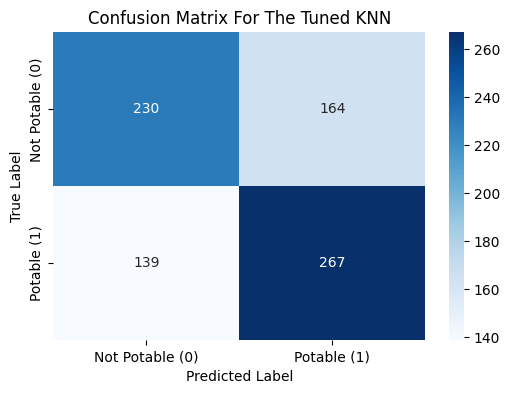

In [88]:
cm = confusion_matrix(y_test, y_pred_best_knn)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Potable (0)', 'Potable (1)'],
            yticklabels=['Not Potable (0)', 'Potable (1)'])
plt.title('Confusion Matrix For The Tuned KNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# **comparison**

In [89]:
results = {
    "Decision Tree (Default)": accuracy_score(y_test, y_pred_dt),
    "Decision Tree (Tuned)": accuracy_score(y_test, y_pred_best_dt),
    "Random Forest (Default)": accuracy_score(y_test, y_pred_rf),
    "Random Forest (Tuned)": accuracy_score(y_test, y_predd_rf),
    "KNN (Default)": accuracy_score(y_test, y_pred_knn),
    "KNN (Tuned)": accuracy_score(y_test, y_pred_best_knn),
    "SVM (Scaled)": accuracy_score(y_test2, y_pred_svm2),
    "SVM (Default)": accuracy_score(y_test, y_pred_svm_default),
    "SVM (Scaled and Tuned)": accuracy_score(y_test2, y_pred_best)
}

results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print(results_df)

                     Model  Accuracy
3    Random Forest (Tuned)  0.716250
2  Random Forest (Default)  0.702500
8   SVM (Scaled and Tuned)  0.681402
6             SVM (Scaled)  0.678354
5              KNN (Tuned)  0.621250
4            KNN (Default)  0.607500
0  Decision Tree (Default)  0.595000
1    Decision Tree (Tuned)  0.586250
7            SVM (Default)  0.512500


In [90]:
joblib.dump(rf, 'water_potability_model (3).pkl')

['water_potability_model (3).pkl']